# Импорт необходимых библиотек и загрузка данных.

In [ ]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional

#nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
lemmatizer= WordNetLemmatizer()

# Modelling
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.svm import SVC

#Lime
from lime import lime_text
from lime.lime_text import LimeTextExplainer
from lime.lime_text import IndexedString,IndexedCharacters
from lime.lime_base import LimeBase
from lime.lime_text import explanation
sns.set(font_scale=1.3)
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3bc6cc8cfa14411cbff7a7558a4e31ee21e117b7b897d863aea8ce47440442c0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [ ]:
import kagglehub
import os
path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")
print("Path to dataset files:", path)

# Выводим список файлов в директории
print("\nFiles in the dataset:")
for file in os.listdir(path):
    print(f"  - {file}")

Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.
Path to dataset files: /kaggle/input/emotions-dataset-for-nlp

Files in the dataset:
  - val.txt
  - test.txt
  - train.txt


In [ ]:
df_train = pd.read_csv(os.path.join(path, 'train.txt'), sep=';', names=['Text', 'Emotion'])
df_val = pd.read_csv(os.path.join(path, 'val.txt'), sep=';', names=['Text', 'Emotion'])
df_test = pd.read_csv(os.path.join(path, 'test.txt'), sep=';', names=['Text', 'Emotion'])

# Display the first 5 rows of df_train
df_train.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
#print the shape of the data set
print(df_train.shape)

(16000, 2)


In [ ]:
#print first 5 rows
df_test.head()

,Text,Emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
#print the shape of the data set
print(df_test.shape)

(2000, 2)


In [ ]:
#print first 5 rows
df_val.head()

,Text,Emotion
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


In [ ]:
#print the shape of the data set
print(df_val.shape)

(2000, 2)


# Train dataset

In [ ]:
#check if the data is balanced or not
df_train.Emotion.value_counts()

,count
Emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [ ]:
#check if the data is balanced or not
df_train.Emotion.value_counts() / df_train.shape[0] *100

,count
Emotion,
joy,33.51250
sadness,29.16250
anger,13.49375
fear,12.10625
love,8.15000
surprise,3.57500


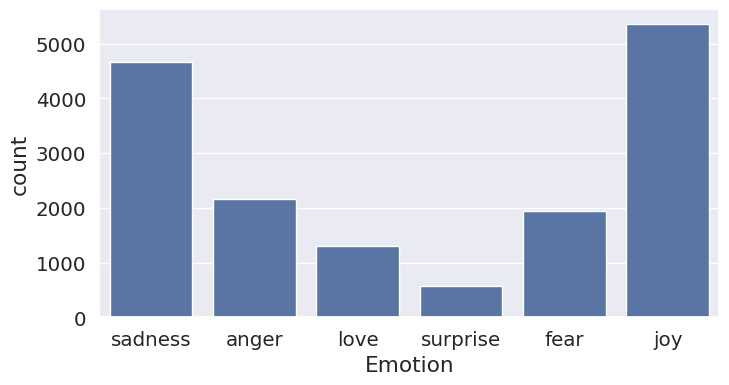

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_train);

Данные несбалансированы, поэтому мы можем попытаться их сбалансировать, но также эмоции, которые нас интересуют, являются наиболее часто повторяющимися

In [ ]:
#print the number of null values in each column
df_train.isnull().sum()

,0
Text,0
Emotion,0


Данные не содержат нулевых значений

In [ ]:
# количество дублированных значений
df_train.duplicated().sum()

np.int64(1)

Есть только одна строка которая дублируется, но нам также нужно проверить, есть ли строки с одинаковым текстом но разными эмоциями





In [ ]:
#removing duplicated values
index = df_train[df_train.duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [ ]:
#покажем строки, которые дублируются (дублируются в тексте, но с разными эмоциями)
df_train[df_train['Text'].duplicated() == True]

,Text,Emotion
5067,i feel on the verge of tears from weariness i ...,joy
6133,i still feel a craving for sweet food,love
6563,i tend to stop breathing when i m feeling stre...,anger
7623,i was intensely conscious of how much cash i h...,sadness
7685,im still not sure why reilly feels the need to...,surprise
8246,i am not amazing or great at photography but i...,love
9596,ive also made it with both sugar measurements ...,joy
9687,i had to choose the sleek and smoother feel of...,joy
9769,i often find myself feeling assaulted by a mul...,sadness
9786,i feel im being generous with that statement,joy


In [ ]:
# некоторые из этих строк
df_train[df_train['Text'] == df_train.iloc[7623]['Text']]

,Text,Emotion
1625,i was intensely conscious of how much cash i h...,anger
7623,i was intensely conscious of how much cash i h...,sadness


In [ ]:
df_train[df_train['Text'] == df_train.iloc[14313]['Text']]

,Text,Emotion
13653,i could feel myself hit this strange foggy wall,fear
14313,i could feel myself hit this strange foggy wall,surprise


In [ ]:
df_train[df_train['Text'] == df_train.iloc[13879]['Text']]

,Text,Emotion
7333,i feel like i am very passionate about youtube...,joy
13879,i feel like i am very passionate about youtube...,love


In [ ]:
# удаление дублированного текста
index = df_train[df_train['Text'].duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [ ]:
# количество стоп-слов в данных
temp =df_train.copy()
stop_words = set(stopwords.words("english"))
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()

,count
stop_words,
5,1416
7,1405
6,1392
4,1341
8,1319
3,1263
9,1177
10,1048
2,922


Данные содержат много стоп-слов (в некоторых строках содержится более 25 стоп-слов!), поэтому нам нужно быть осторожными при их удалении, так как некоторые строки могут стать пустыми

<Axes: ylabel='Frequency'>

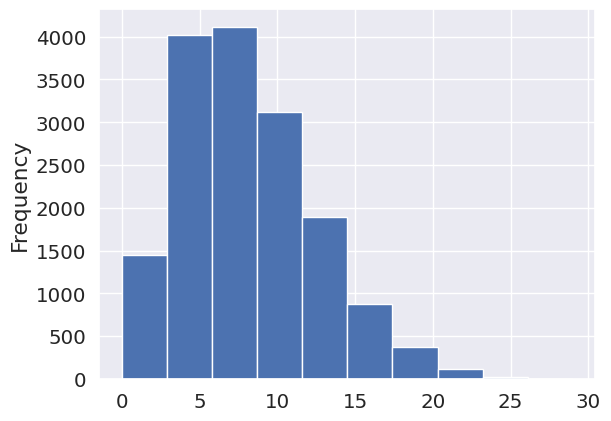

In [ ]:
# визуальное распределение стоп-слов
temp['stop_words'].plot(kind= 'hist')

# **Test dataset**

In [ ]:
# проверяем, сбалансированы ли данные
df_test.Emotion.value_counts()

,count
Emotion,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


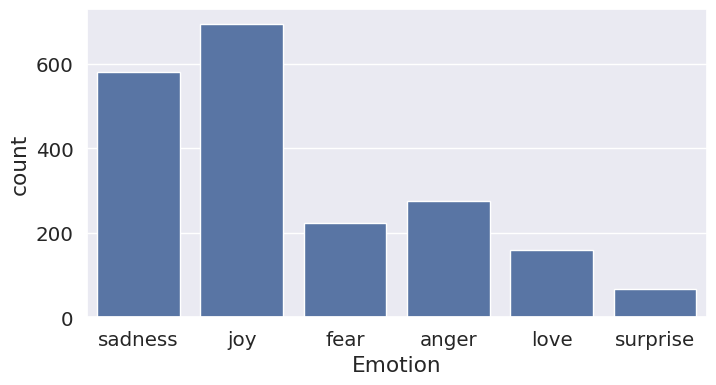

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_test);

In [ ]:
# количество нулевых значений в каждом столбце
df_test.isnull().sum()

,0
Text,0
Emotion,0


In [ ]:
# количество дублированных значений
df_test.duplicated().sum()

np.int64(0)

In [ ]:
# строки, которые дублируются
df_test[df_test['Text'].duplicated() == True]

,Text,Emotion


In [ ]:
# количество стоп-слов в данных
temp =df_test.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()

,count
stop_words,
7,184
6,179
3,175
5,175
4,163
9,163
8,139
10,123
2,118


<Axes: ylabel='Frequency'>

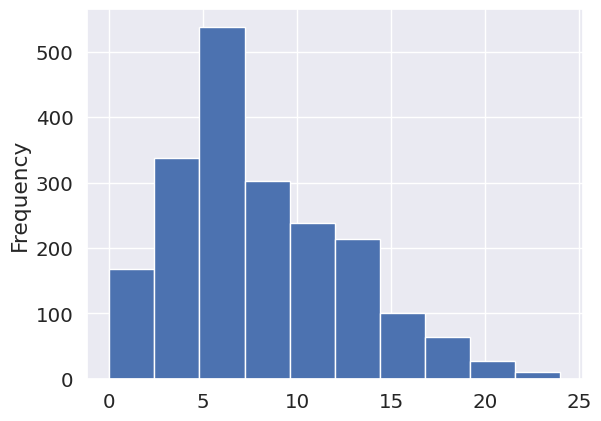

In [ ]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist')

# Validation dataset

In [ ]:
#check if the data is balanced or not
df_val.Emotion.value_counts()

,count
Emotion,
joy,704
sadness,550
anger,275
fear,212
love,178
surprise,81


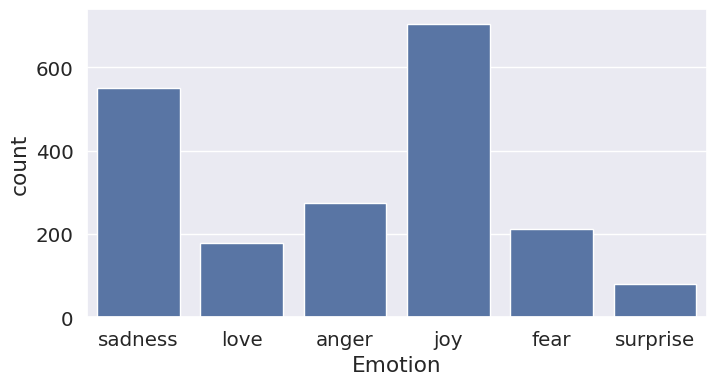

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_val);

In [ ]:
# количество нулевых значений в каждом столбце
df_val.isnull().sum()

,0
Text,0
Emotion,0


In [ ]:
# количество дублированных значений
df_val.duplicated().sum()

np.int64(0)

In [ ]:
# строки, которые дублируются
df_val[df_val['Text'].duplicated() == True]

,Text,Emotion
603,i have had several new members tell me how com...,joy
1993,i feel so tortured by it,anger


In [ ]:
df_val[df_val['Text'] == df_val.iloc[603]['Text']]

,Text,Emotion
300,i have had several new members tell me how com...,love
603,i have had several new members tell me how com...,joy


In [ ]:
df_val[df_val['Text'] == df_val.iloc[1993]['Text']]

,Text,Emotion
774,i feel so tortured by it,fear
1993,i feel so tortured by it,anger


In [ ]:
# удалим дублированный текст
index = df_val[df_val['Text'].duplicated() == True].index
df_val.drop(index, axis = 0, inplace = True)
df_val.reset_index(inplace=True, drop = True)

In [ ]:
# Подсчитаем количество стоп-слов в данных
temp =df_val.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()[:10]

,count
stop_words,
7,190
5,175
8,173
3,160
6,160
10,150
9,146
4,145
2,133


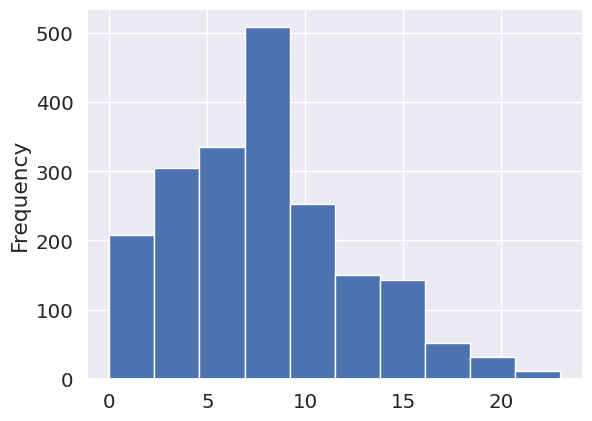

In [ ]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist');

# Сравнение строк набора данных


убедимся в отсутствии утечки данных

In [ ]:
def dataframe_difference(df1, df2, which=None):
    """Find rows which are different between two DataFrames."""

    # Объедените два фрейма данных, используя операцию слияния.
    # indicator, равным True. При этом в результирующий фрейм данных добавляется столбец с именем _merge
    # который указывает источник каждой строки.
    comparison_df = df1.merge(
        df2,
        indicator=True,
        how='outer'
    )

    # Отфильтруем объединенный фрейм данных на основе значения _merge. Если значение which
    # не указано, вернем все строки, в которых _merge не является "both".
    # В противном случае вернем все строки, в которых _merge имеет указанное значение
    if which is None:
        diff_df = comparison_df[comparison_df['_merge'] != 'both']
    else:
        diff_df = comparison_df[comparison_df['_merge'] == which]

    # Возвращает отфильтрованный фрейм данных
    return diff_df

In [ ]:
dataframe_difference(df_train, df_val, which='both')

,Text,Emotion,_merge


Отчистка **данных**

In [ ]:
def lemmatization(text):
    lemmatizer= WordNetLemmatizer()

    text = text.split()

    text=[lemmatizer.lemmatize(y) for y in text]

    return " " .join(text)

def remove_stop_words(text):

    Text=[i for i in str(text).split() if i not in stop_words]
    return " ".join(Text)

def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

def lower_case(text):

    text = text.split()

    text=[y.lower() for y in text]

    return " " .join(text)

def Removing_punctuations(text):
    ## Remove punctuations
    text = re.sub(r'[%s]' % re.escape(r"""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    text = text.replace('؛',"", )

    ## remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_small_sentences(df):
    for i in range(len(df)):
        if len(df.text.iloc[i].split()) < 3:
            df.text.iloc[i] = np.nan

def normalize_text(df):
    df.Text=df.Text.apply(lambda text : lower_case(text))
    df.Text=df.Text.apply(lambda text : remove_stop_words(text))
    df.Text=df.Text.apply(lambda text : Removing_numbers(text))
    df.Text=df.Text.apply(lambda text : Removing_punctuations(text))
    df.Text=df.Text.apply(lambda text : Removing_urls(text))
    df.Text=df.Text.apply(lambda text : lemmatization(text))
    return df

def normalized_sentence(sentence):
    sentence= lower_case(sentence)
    sentence= remove_stop_words(sentence)
    sentence= Removing_numbers(sentence)
    sentence= Removing_punctuations(sentence)
    sentence= Removing_urls(sentence)
    sentence= lemmatization(sentence)
    return sentence

In [ ]:
normalized_sentence("My Name is Dmitrii. @Tweets,  plays 2026  Russia_")

'name dmitrii tweet play russia'

In [ ]:
df_train= normalize_text(df_train)
df_test= normalize_text(df_test)
df_val= normalize_text(df_val)

# Моделирование

TF-IDF
При подсчете слов возникают некоторые проблемы: наиболее часто встречающиеся слова обычно не важны (например, стоп-слова), хотя они требуют большого внимания.

TFIDF (Term Frequency - Inverse Document) - это способ скорректировать это количество:

TF: упоминания в документе

IDF: упоминания во всех документах

Таким образом, во всех документах большее значение придается редким словам (IDF++, TFIDF--), в то время как основное внимание уделяется словам, которые чаще всего встречаются в этом документе (TF++, TFIDF--).

Если слово встречается только в текущем документе/предложении, оно имеет значение TFIDF=1. Если слово встречается во всех документах/предложениях, но не в текущем, оно имеет значение TFIDF=0. Если слово (например, стоп-слово) часто встречается в текущем документе/отправленном сообщении, а также во всех других, у него будет высокий TF  и гораздо более высокий IDF, поэтому в целом TFIDF будет низким.

**Начнем с базовых моделей**
Создание графической линии с использованием tf-idf для встраивания слов и различных моделей.

In [ ]:
# Предварительная обработка текста
X_train = df_train['Text'].values
y_train = df_train['Emotion'].values

X_test = df_test['Text'].values
y_test = df_test['Emotion'].values

X_val = df_val['Text'].values
y_val = df_val['Emotion'].values

In [ ]:
def train_model(model, data, targets):
    """
    Обучим модель на основе заданных данных и целевых показателей.

    Параметры:
    модель (sklearn model): Модель, подлежащая обучению.
    данные (список str): Входные данные.
    цели (список str): Целевые объекты.

    Возвращается:
    Обученная модель как объект Pipeline.
    """
    # Create a Pipeline object with a TfidfVectorizer and the given model
    text_clf = Pipeline([('vect',TfidfVectorizer()),
                         ('clf', model)])
    # Fit the model on the data and targets
    text_clf.fit(data, targets)
    return text_clf

In [ ]:
def get_F1(trained_model,X,y):
    """
    Получим оценку F1 для данной модели на основе заданных данных и целевых показателей.

    Параметры:
    trained_model (модель sklearn): Обученная модель.
    X (список str): Входные данные.
    y (список str): Целевые объекты.

    Возвращается:
    массив: оценка F1 для каждого класса.
    """
    # Make predictions on the input data using the trained model
    predicted=trained_model.predict(X)
    # Calculate the F1 score for the predictions
    f1=f1_score(y,predicted, average=None)
    # Return the F1 score
    return f1

# **Обучение модели логистической регрессии на обучающем наборе данных**

In [ ]:
# Обучаем модель с помощью обучающих данных
log_reg = train_model(LogisticRegression(solver='liblinear',random_state = 0), X_train, y_train)

In [ ]:
#Сделаем одно-единственное предсказание
y_pred=log_reg.predict(['Happy'])
y_pred

array(['joy'], dtype=object)

In [ ]:
# протестируем модель с помощью тестовых данных
y_pred=log_reg.predict(X_test)

# рассчитаем точность
log_reg_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', log_reg_accuracy,'\n')

# расчитаем F1 балл
f1_Score = get_F1(log_reg,X_test,y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.8685 



,F1 score
sadness,0.858223
anger,0.823810
love,0.893048
surprise,0.703704
fear,0.915683
joy,0.626263


In [ ]:
# Отчет классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.89      0.83      0.86       275
        fear       0.88      0.77      0.82       224
         joy       0.83      0.96      0.89       695
        love       0.86      0.60      0.70       159
     sadness       0.90      0.93      0.92       581
    surprise       0.94      0.47      0.63        66

    accuracy                           0.87      2000
   macro avg       0.88      0.76      0.80      2000
weighted avg       0.87      0.87      0.86      2000



# **Модель Decision Tree (дерево решений) на тренировочном наборе данных.**

In [ ]:
# Обучаем модель с помощью обучающих данных
DT = train_model(DecisionTreeClassifier(random_state = 0), X_train, y_train)

# Тестируем
y_pred=DT.predict(X_test)

# Точность
DT_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', DT_accuracy,'\n')

# расчитаем F1 балл
f1_Score = get_F1(DT,X_test,y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.862 



,F1 score
sadness,0.856115
anger,0.815789
love,0.894737
surprise,0.753799
fear,0.903896
joy,0.617647


In [ ]:
# Отчет классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.85      0.87      0.86       275
        fear       0.80      0.83      0.82       224
         joy       0.91      0.88      0.89       695
        love       0.73      0.78      0.75       159
     sadness       0.91      0.90      0.90       581
    surprise       0.60      0.64      0.62        66

    accuracy                           0.86      2000
   macro avg       0.80      0.82      0.81      2000
weighted avg       0.86      0.86      0.86      2000



# **Модель Support Vector Machine (SVM, метод опорных векторов) на тренировочном наборе данных.**

In [ ]:
# Обучаем модель с помощью обучающих данных
SVM = train_model(SVC(random_state = 0), X_train, y_train)

# Тестируем
y_pred=SVM.predict(X_test)

# Точность
SVM_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', SVM_accuracy,'\n')

# Расчитаем F1 балл
f1_Score = get_F1(SVM,X_test,y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.8675 



,F1 score
sadness,0.857685
anger,0.827907
love,0.893645
surprise,0.681648
fear,0.914821
joy,0.654206


In [ ]:
# Отчет классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.90      0.82      0.86       275
        fear       0.86      0.79      0.83       224
         joy       0.83      0.96      0.89       695
        love       0.84      0.57      0.68       159
     sadness       0.91      0.92      0.91       581
    surprise       0.85      0.53      0.65        66

    accuracy                           0.87      2000
   macro avg       0.87      0.77      0.80      2000
weighted avg       0.87      0.87      0.86      2000



# Обучение модели Random Forest (случайного леса) на обучающем наборе.

In [ ]:
# Обучаем модель с помощью обучающих данных
RF = train_model(RandomForestClassifier(random_state = 0), X_train, y_train)

# Тестируем
y_pred=RF.predict(X_test)

# Точность
RF_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', RF_accuracy,'\n')

# Расчитаем F1 балл
f1_Score = get_F1(RF, X_test, y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.8835 



,F1 score
sadness,0.888483
anger,0.869565
love,0.903497
surprise,0.732673
fear,0.929701
joy,0.622951


In [ ]:
# Отчет классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.89      0.88      0.89       275
        fear       0.85      0.89      0.87       224
         joy       0.88      0.93      0.90       695
        love       0.77      0.70      0.73       159
     sadness       0.95      0.91      0.93       581
    surprise       0.68      0.58      0.62        66

    accuracy                           0.88      2000
   macro avg       0.84      0.82      0.82      2000
weighted avg       0.88      0.88      0.88      2000



# Результаты

In [ ]:
import pandas as pd

models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree','Support Vector Machine','Random Forest'],
    'Accuracy': [round(0.8685, 2), round(0.862, 2), round(0.8675, 2), round(0.8835, 2)]})

models.sort_values(by='Accuracy', ascending=False).reset_index().drop(['index'], axis=1)

,Model,Accuracy
0,Random Forest,0.88
1,Logistic Regression,0.87
2,Support Vector Machine,0.87
3,Decision Tree,0.86


# Лайм
LIME, аббревиатура от local interpretable model - независимые объяснения, - это метод, который объединяет любую модель машинного обучения "черного ящика" с локальной интерпретируемой моделью для объяснения каждого отдельного предсказания

нам нужно знать, какие слова внесли наибольший вклад в предсказание

In [ ]:
#c_LR = make_pipeline(tfidf, clf)
explainer_LR = LimeTextExplainer(class_names=RF.classes_)
idx  = 15
print("Actual Text : ", X_test[idx])
print("Prediction : ", RF.predict(X_test)[idx])
print("Actual :     ", y_test[idx])
exp = explainer_LR.explain_instance(X_test[idx], RF.predict_proba,top_labels=5)
exp.show_in_notebook()

Actual Text :  feeling heartbroken im sure katniss
Prediction :  sadness
Actual :      sadness


# Подготовка данных для глубокого обучения
**Попробуем** заменить TF‑IDF на GloVe embeddings — вместо разреженных векторов с частотами слов использовать плотные векторы, где каждое слово представлено как многомерный вектор, кодирующий семантику.

In [ ]:
# Разделим текстовые данные и метки
X_train = df_train['Text']
y_train = df_train['Emotion']

X_test = df_test['Text']
y_test = df_test['Emotion']

X_val = df_val['Text']
y_val = df_val['Emotion']

In [ ]:
# Кодирование меток
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_val = le.transform(y_val)

In [ ]:
# Метки после кодирования
print(set(y_train))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}


In [ ]:
# Преобразуем вектор классов (целые числа) в двоичную матрицу классов
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_val = to_categorical(y_val)

In [ ]:
print(y_train)

[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]]


**Токенизация**

In [ ]:
# Tokenize words
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(pd.concat([X_train, X_test], axis=0))

In [ ]:
# количество документов: словарь слов и количество документов, в которых каждый из них появился.
# в этом наборе данных результатом будет количество строк
tokenizer.document_count

17969

In [ ]:
# возвращает числовой индекс слова, если оно есть в словаре.
tokenizer.word_index['towards']

220

In [ ]:
# преобразование одного предложения в список индексов
tokenizer.texts_to_sequences(X_train[0].split())

[[53], [2], [531]]

In [ ]:
# преобразуем список индексов в матрицу из единиц и нулей (BOW)
tokenizer.texts_to_matrix(X_train[0].split())

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# предложение состоит из трех слов, а словарный запас составляет 14332
tokenizer.texts_to_matrix(X_train[0].split()).shape

(3, 14332)

In [ ]:
sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test = tokenizer.texts_to_sequences(X_test)
sequences_val = tokenizer.texts_to_sequences(X_val)

Padding

Векторы, которые мы получаем, как правило, не имеют одинаковой длины

Для этого нам может потребоваться увеличить последовательности до максимальной длины.

In [ ]:
df_test.shape

(2000, 2)

In [ ]:
maxlen = max([len(t) for t in df_train['Text']])
maxlen

229

In [ ]:
X_train = pad_sequences(sequences_train, maxlen=229, truncating='pre')
X_test = pad_sequences(sequences_test, maxlen=229, truncating='pre')
X_val = pad_sequences(sequences_val, maxlen=229, truncating='pre')

vocabSize = len(tokenizer.index_word) + 1
print(f"Vocabulary size = {vocabSize}")

Vocabulary size = 14332


In [ ]:
# До
sequences_train[0]

[53, 2, 531]

In [ ]:
# После
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

Word Embedding


Этот код определяет следующие переменные:

path_to_glove_file: Путь к файлу GloVe word vectors.

num_tokens: Размер словаря. Обычно это количество уникальных слов в наборе данных.

embedding_dim: размерность векторов word. Обычно для этого параметра устанавливается фиксированное значение (например, 200, 300 и т.д.) в зависимости от размера используемого файла word vectors.

hits: счетчик количества слов, найденных в словаре embeddings_index.

misses: счетчик количества слов, которые не найдены в словаре embeddings_index.

embeddings_index: Словарь, в котором будут храниться векторы слов, со словами в качестве ключей и векторами слов в качестве значений.

In [ ]:
# Read GloVE embeddings

path_to_glove_file = '../input/glove-global-vectors-for-word-representation/glove.6B.200d.txt'
num_tokens = vocabSize
embedding_dim = 200 #latent factors or features
hits = 0
misses = 0
embeddings_index = {}

Я инициализирую матрицу встраивания со всеми нулевыми значениями, а затем перебираю словарь (как определено объектом tokenizer), чтобы присвоить векторы слов соответствующим строкам матрицы встраивания. Атрибут word_index объекта tokenizer - это словарь, который сопоставляет слова с их индексами в словаре.

Матрица встраивания будет иметь размер строк num_tokens и столбцов embedding_dim, где num_tokens - это размер словаря, а embedding_dim - размерность векторов слов.

Для каждого слова в словаре код ищет соответствующий вектор слов в словаре embeddings_index и присваивает его соответствующей строке матрицы встраивания. Если слово не найдено в словаре embeddings_index (т.е. если значение embedding_vector равно None), код увеличивает счетчик пропусков, и строка матрицы внедрения остается полной нулей. Если слово найдено в словаре embeddings_index, код увеличивает счетчик совпадений и присваивает вектор слов соответствующей строке матрицы встраивания. Наконец, код выводит количество слов, которые были преобразованы (совпадения), и количество слов, которые не были найдены в словаре embeddings_index (пропуски).

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-16 10:56:03--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-16 10:56:03--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-16 10:56:04--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip -q glove.6B.zip

In [ ]:
# Read GloVE embeddings

path_to_glove_file = 'glove.6B.200d.txt' # Updated path to point to the extracted file
num_tokens = vocabSize
embedding_dim = 200 #latent factors or features
hits = 0
misses = 0
embeddings_index = {}

In [ ]:
# Read word vectors
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs
print("Found %s word vectors." % len(embeddings_index))

# Assign word vectors to our dictionary/vocabulary
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Found 400000 word vectors.
Converted 13249 words (1082 misses)


# Моделирование

Модель состоит из нескольких слоев:

1. Слой внедрения, который принимает текст в кодировке целых чисел и ищет вектор внедрения для каждого слова во входных данных. Длина входных данных устанавливается равной длине входных последовательностей, а веса инициализируются с помощью матрицы внедрения, которая была предварительно обработана на большом наборе данных. Слой внедрения не поддается обучению, что означает, что веса этого слоя не будут обновляться во время обучения.

2. Три двунаправленных уровня, каждый из которых применяет прямой и обратный LSTM к входным данным. LSTM - это тип рекуррентной нейронной сети, которая способна фиксировать долгосрочные зависимости в последовательных данных. Аргументы dropout и recurrent dropout определяют частоту отсева, применяемую к входам и рекуррентным вводам LSTM, соответственно. Аргумент return_sequences указывает, должна ли LSTM возвращать полные последовательности выходных данных или только последний вывод каждой последовательности.

3. Плотный слой, который применяет линейное преобразование к входным данным для получения выходных данных. Выходные данные состоят из 6 единиц и используют функцию активации "softmax", что означает, что они будут отображать распределение вероятностей по 6 классам.

Начнем с одного Двунаправленного слоя, после увеличим до трех и посмотрим разницу.

In [ ]:
adam = Adam(learning_rate=0.005)

model = Sequential()
model.add(Embedding(vocabSize, 200, input_length=X_train.shape[1], weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(256, dropout=0.2,recurrent_dropout=0.2, return_sequences=True)))
model.add(Dense(6, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,866,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,400 (10.93 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,866,400 (10.93 MB)

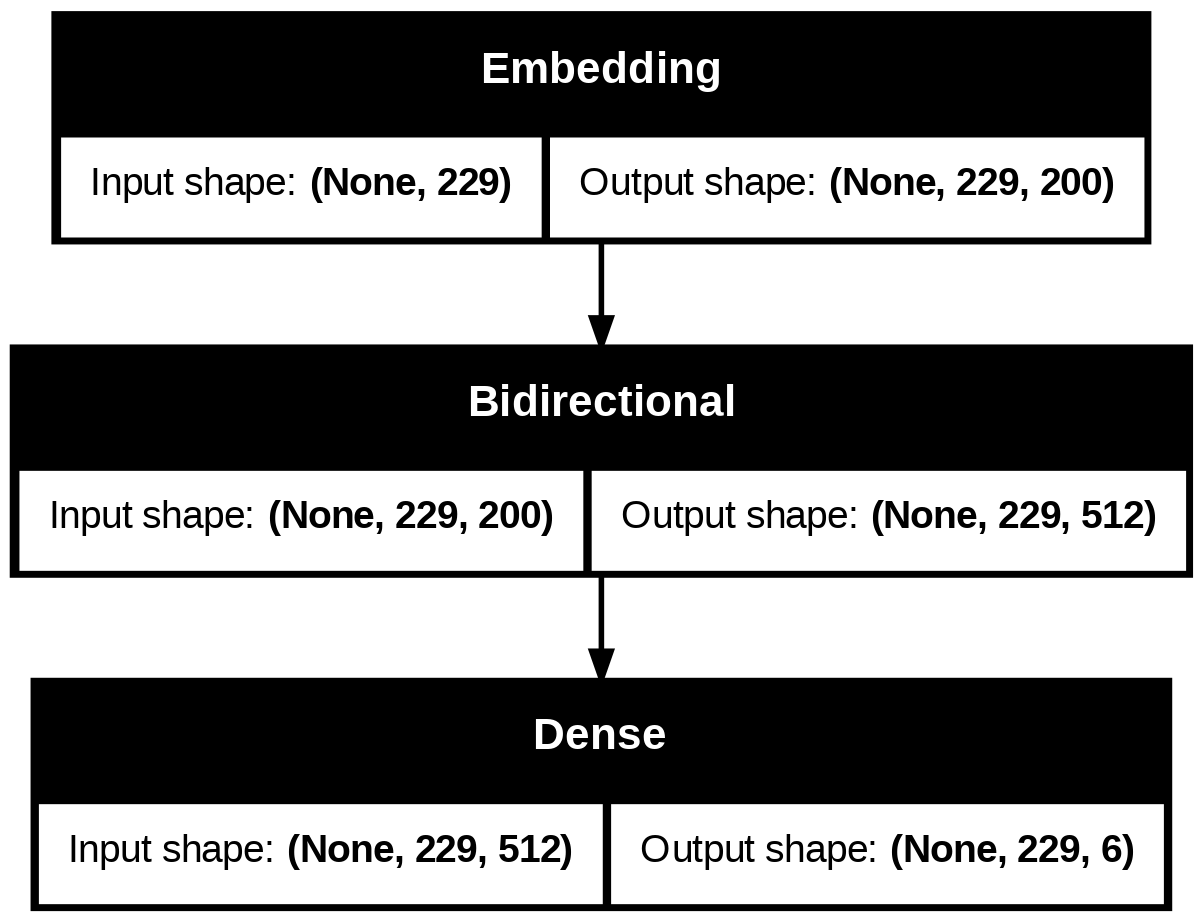

In [ ]:
from tensorflow.keras.utils import plot_model

# Define max_sequence_length using the previously calculated maxlen
max_sequence_length = maxlen

# Explicitly build the model with the expected input shape
model.build(input_shape=(None, max_sequence_length))

plot_model(model, show_shapes=True)

In [ ]:
# прекратить тренировку, когда потери начнут увеличиваться.
callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

In [ ]:
adam = Adam(learning_rate=0.005)

model_single_bidirectional = Sequential()
model_single_bidirectional.add(Embedding(vocabSize, 200, input_length=X_train.shape[1], weights=[embedding_matrix], trainable=False))
model_single_bidirectional.add(Bidirectional(LSTM(256, dropout=0.2, recurrent_dropout=0.2)))
model_single_bidirectional.add(Dense(6, activation='softmax'))

model_single_bidirectional.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model_single_bidirectional.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,866,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,400 (10.93 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,866,400 (10.93 MB)

In [ ]:
history_single_bidirectional = model_single_bidirectional.fit(X_train,
                    y_train,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    batch_size=256,
                    epochs=30,
                    callbacks=[callback]
                   )

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 655s 10s/step - accuracy: 0.6215 - loss: 1.0247 - val_accuracy: 0.8308 - val_loss: 0.4860
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 616s 10s/step - accuracy: 0.8507 - loss: 0.4007 - val_accuracy: 0.9004 - val_loss: 0.2601
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 632s 10s/step - accuracy: 0.9076 - loss: 0.2426 - val_accuracy: 0.9194 - val_loss: 0.1903
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 633s 10s/step - accuracy: 0.9327 - loss: 0.1687 - val_accuracy: 0.9239 - val_loss: 0.1717
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 630s 10s/step - accuracy: 0.9436 - loss: 0.1325 - val_accuracy: 0.9184 - val_loss: 0.1608
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 612s 10s/step - accuracy: 0.9575 - loss: 0.1046 - val_accuracy: 0.9199 - val_loss: 0.1895
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 630s 10s/step - accuracy: 0.9651 - loss: 0.0841 - val_accuracy: 0.9294 - val_loss: 0.1637
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 609s 10s/step - accuracy: 0.9713 - loss: 0.0746 - val_accuracy: 0.

In [ ]:
print("Evaluating the model with a single bidirectional LSTM layer on the test set:")
loss_single, accuracy_single = model_single_bidirectional.evaluate(X_test, y_test, verbose=0)
print(f"Overall Accuracy (Single Bidirectional LSTM Model): {accuracy_single:.4f}")

Evaluating the model with a single bidirectional LSTM layer on the test set:
Overall Accuracy (Single Bidirectional LSTM Model): 0.9280


### Learning Curves for Single Bidirectional LSTM Model

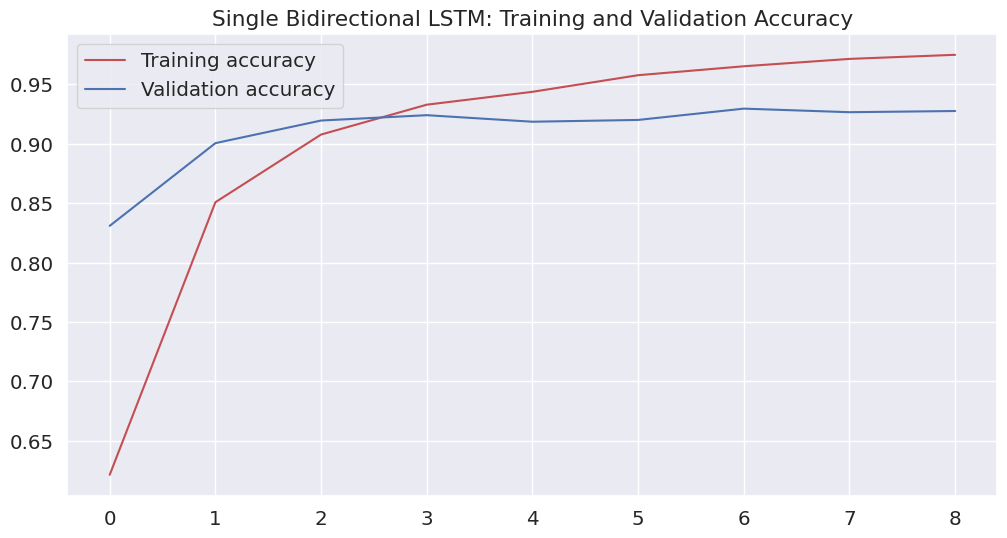

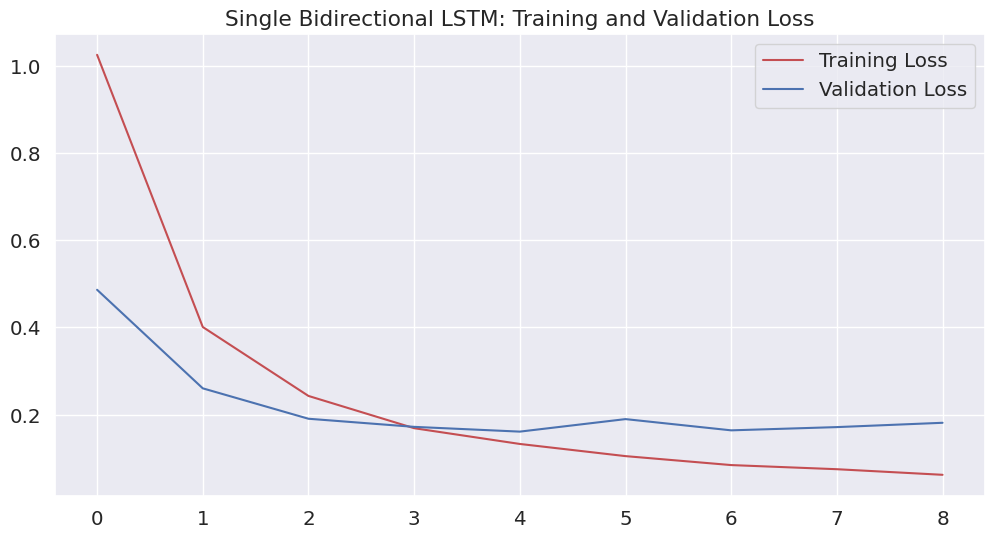

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

acc_single = history_single_bidirectional.history['accuracy']
val_acc_single = history_single_bidirectional.history['val_accuracy']
loss_single = history_single_bidirectional.history['loss']
val_loss_single = history_single_bidirectional.history['val_loss']

epochs_single = range(len(acc_single))

plt.figure(figsize=(12, 6))
plt.plot(epochs_single, acc_single, 'r', label='Training accuracy')
plt.plot(epochs_single, val_acc_single, 'b', label='Validation accuracy')
plt.title('Single Bidirectional LSTM: Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_single, loss_single, 'r', label='Training Loss')
plt.plot(epochs_single, val_loss_single, 'b', label='Validation Loss')
plt.title('Single Bidirectional LSTM: Training and Validation Loss')
plt.legend()
plt.show()

### Learning Curves for Triple Bidirectional LSTM Model

In [ ]:
adam = Adam(learning_rate=0.005)

model = Sequential()
model.add(Embedding(vocabSize, 200, input_length=X_train.shape[1], weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(256, dropout=0.2,recurrent_dropout=0.2, return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.2,recurrent_dropout=0.2, return_sequences=True)))
model.add(Bidirectional(LSTM(128, dropout=0.2,recurrent_dropout=0.2, return_sequences=False))) # Explicitly set to False
model.add(Dense(6, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,866,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,400 (10.93 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,866,400 (10.93 MB)

Это краткое описание модели глубокого обучения, построенной с использованием функционального API Keras. Модель состоит из нескольких уровней, каждый из которых имеет определенный тип и количество параметров.

Первый слой - это слой "встраивания", который принимает текст в кодировке целых чисел и ищет вектор встраивания для каждого слова во входных данных. Результатом работы этого слоя является трехмерный тензор формы (batch_size, sequence_length, embedding_dim), где batch_size - это количество примеров в пакете, sequence_length - длина входных последовательностей, а embedding_dim - размер векторов для встраивания. В этом случае длина входных последовательностей составляет 229 слов, а векторы внедрения - 200 измерений. Уровень внедрения содержит в общей сложности 2 863 600 обучаемых параметров.

Следующие три уровня являются "двунаправленными" слоями, которые применяют прямой и обратный LSTM к входным данным. LSTM - это тип рекуррентной нейронной сети, которая способна фиксировать долгосрочные зависимости в последовательных данных. Результатом работы каждого двунаправленного слоя является трехмерный тензор формы (batch_size, sequence_length, units), где units - это количество единиц измерения LSTM в слое. В этом случае первый двунаправленный уровень содержит 512 единиц, второй - 256 единиц, а третий - 256 единиц. Каждый из этих уровней имеет большое количество обучаемых параметров, поскольку LSTM - это сложные модели со многими внутренними весами.

Последний слой - это "плотный" слой, который применяет линейное преобразование к входным данным для получения выходных данных. В этом случае выходные данные имеют форму (batch_size, 6), что указывает на наличие 6 классов. Плотный слой содержит в общей сложности 1542 обучаемых параметра.

В целом, модель содержит в общей сложности 4 851 702 обучаемых параметра и 2 863 600 необучаемых параметров.

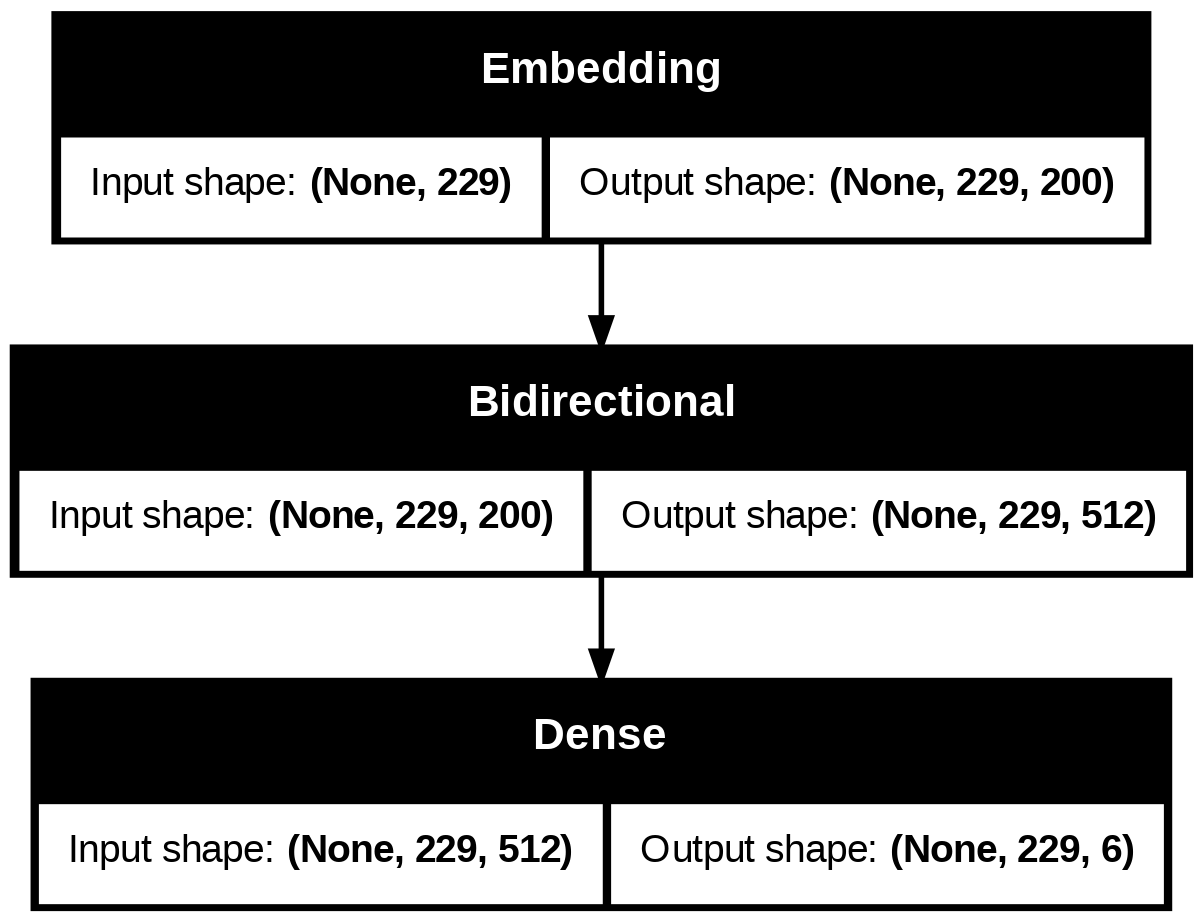

In [ ]:
from tensorflow.keras.utils import plot_model

# Explicitly build the model with the expected input shape
model.build(input_shape=(None, max_sequence_length))

plot_model(model, show_shapes=True)

In [ ]:
# прекратить тренировку, когда потери начнут увеличиваться.
callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

In [ ]:
# Fit model
history = model.fit(X_train,
                    y_train,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    batch_size=256,
                    epochs=30,
                    callbacks=[callback]
                   )

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1654s 26s/step - accuracy: 0.5805 - loss: 1.1248 - val_accuracy: 0.8083 - val_loss: 0.5430
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1572s 25s/step - accuracy: 0.8461 - loss: 0.4266 - val_accuracy: 0.8949 - val_loss: 0.2582
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1555s 25s/step - accuracy: 0.9126 - loss: 0.2227 - val_accuracy: 0.9124 - val_loss: 0.2051
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1601s 25s/step - accuracy: 0.9341 - loss: 0.1490 - val_accuracy: 0.9294 - val_loss: 0.1446
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1582s 25s/step - accuracy: 0.9407 - loss: 0.1244 - val_accuracy: 0.9279 - val_loss: 0.1425
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1592s 25s/step - accuracy: 0.9462 - loss: 0.1056 - val_accuracy: 0.9369 - val_loss: 0.1263
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1638s 25s/step - accuracy: 0.9523 - loss: 0.0942 - val_accuracy: 0.9329 - val_loss: 0.1442
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1588s 25s/step - accuracy: 0.9555 - loss: 0.0899 - val_accu

In [ ]:
#print the overall loss and accuracy
model.evaluate(X_val, y_val, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9369 - loss: 0.1263


[0.12634603679180145, 0.9369369149208069]

In [ ]:
# общие потери и точность
model.evaluate(X_test, y_test, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9300 - loss: 0.1430


[0.14301741123199463, 0.9300000071525574]

In [ ]:
predicted = model.predict(X_test)
y_pred = predicted.argmax(axis=-1)

print(classification_report(le.transform(df_test['Emotion']), y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       275
           1       0.87      0.95      0.90       224
           2       0.98      0.92      0.95       695
           3       0.76      0.96      0.85       159
           4       0.98      0.95      0.96       581
           5       0.82      0.76      0.79        66

    accuracy                           0.93      2000
   macro avg       0.89      0.91      0.90      2000
weighted avg       0.94      0.93      0.93      2000



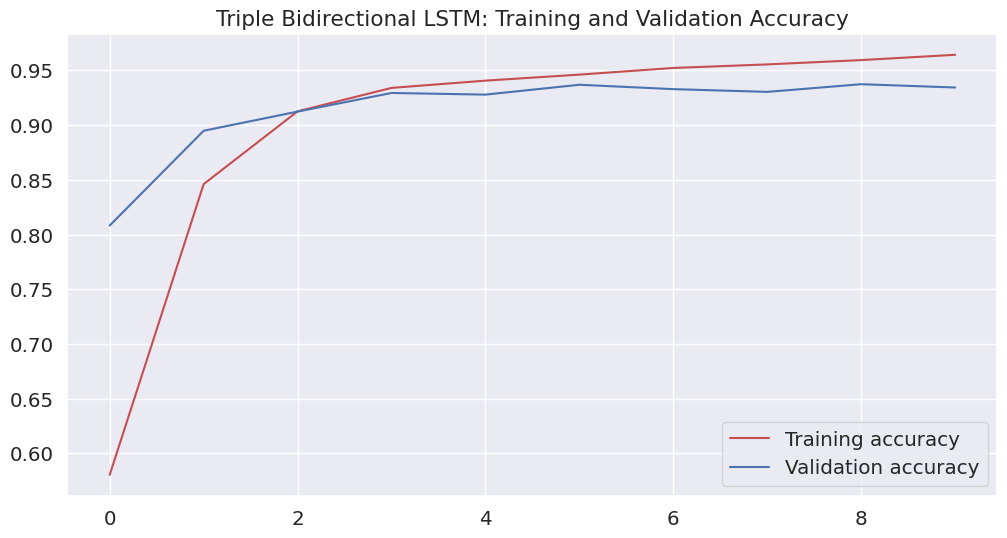

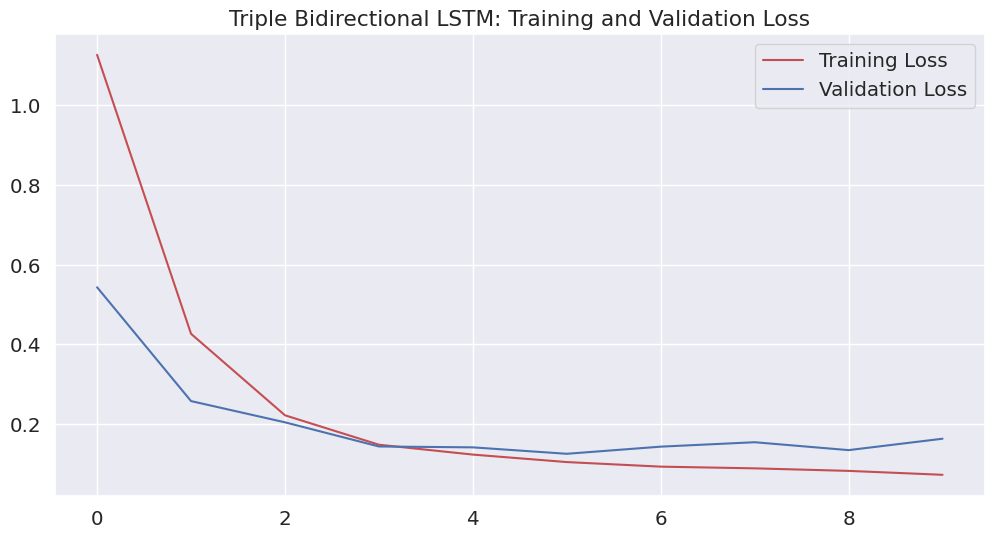

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

acc_triple = history.history['accuracy']
val_acc_triple = history.history['val_accuracy']
loss_triple = history.history['loss']
val_loss_triple = history.history['val_loss']

epochs_triple = range(len(acc_triple))

plt.figure(figsize=(12, 6))
plt.plot(epochs_triple, acc_triple, 'r', label='Training accuracy')
plt.plot(epochs_triple, val_acc_triple, 'b', label='Validation accuracy')
plt.title('Triple Bidirectional LSTM: Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_triple, loss_triple, 'r', label='Training Loss')
plt.plot(epochs_triple, val_loss_triple, 'b', label='Validation Loss')
plt.title('Triple Bidirectional LSTM: Training and Validation Loss')
plt.legend()
plt.show()

Итак, вы можете спросить, когда я задаю предложение модели, как будет выполнена классификация?

Сначала модель преобразует слова в предложении в числовые представления, также известные как встраивание слов. Эти вложения слов фиксируют значение слов и их взаимосвязи друг с другом в непрерывном векторном пространстве.

Вложения слов для каждого слова в предложении затем вводятся в две отдельные модели LSTM: одну, которая обрабатывает последовательность в прямом направлении, и другую, которая обрабатывает ее в обратном направлении. На каждом временном шаге каждый LSTM обрабатывает текущее вложение слов и предыдущее скрытое состояние, чтобы создать новое скрытое состояние. Скрытое состояние на каждом временном шаге представляет собой комбинацию предыдущего скрытого состояния и текущего входного сигнала, и оно фиксирует информацию со всех предыдущих временных шагов в последовательности.

После обработки всех слов в предложении две LSTM будут иметь конечные скрытые состояния, которые кодируют значение предложения как в прямом, так и в обратном направлениях. Затем эти конечные скрытые состояния объединяются и используются для составления прогноза.

### Examples where True Label was 'anger' but Predicted as 'joy'

In [ ]:
misclassified_anger_as_joy_indices = []
for i in range(len(y_true)):
    if y_true[i] == 'anger' and y_pred_labels[i] == 'joy':
        misclassified_anger_as_joy_indices.append(i)

print(f"Found {len(misclassified_anger_as_joy_indices)} examples.")
if misclassified_anger_as_joy_indices:
    for idx in misclassified_anger_as_joy_indices[:5]: # Display up to 5 examples
        print(f"Original Text: {df_test.iloc[idx]['Text']}")
        print(f"True Emotion: {y_true[idx]}, Predicted Emotion: {y_pred_labels[idx]}\n")
else:
    print("No examples found where 'anger' was misclassified as 'joy'.")

Found 4 examples.
Original Text: watched news tv
True Emotion: anger, Predicted Emotion: joy

Original Text: playing sport advanced pe class many people advanced
True Emotion: anger, Predicted Emotion: joy

Original Text: whenever put others shoe try make person happy
True Emotion: anger, Predicted Emotion: joy

Original Text: feeling like said humour get im one people even spoke issue one would bothered would care thought head wasnt true way like dont want burden sort thing
True Emotion: anger, Predicted Emotion: joy



63/63 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step


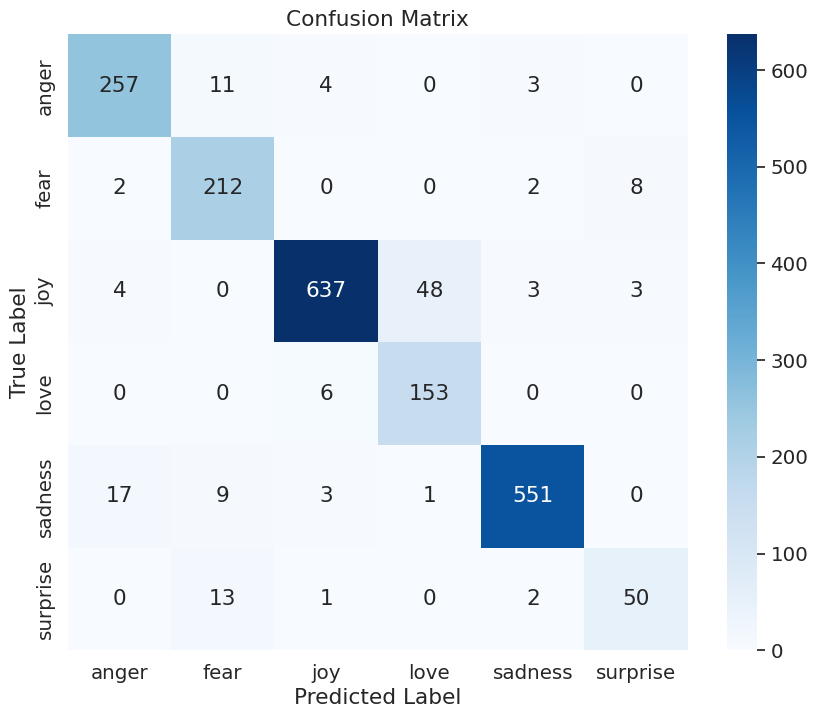

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels from one-hot encoded y_test
y_true = le.inverse_transform(np.argmax(y_test, axis=-1))

# Get predicted labels from the model
predicted_probs = model.predict(X_test)
y_pred_labels = le.inverse_transform(np.argmax(predicted_probs, axis=-1))

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred_labels, labels=le.classes_)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Классифицировать пользовательский образец

sentences = [
            "He's over the moon about being accepted to the university",
            "Your point on this certain matter made me outrageous, how can you say so? This is insane.",
            "I can't do it, I'm not ready to lose anything, just leave me alone",
            "Merlin's beard harry, you can cast the Patronus charm! I'm amazed!"
            ]
for sentence in sentences:
    print(sentence)
    sentence = normalized_sentence(sentence)
    sentence = tokenizer.texts_to_sequences([sentence])
    sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
    result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
    proba =  np.max(model.predict(sentence))
    print(f"{result} : {proba}\n\n")

He's over the moon about being accepted to the university
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
joy : 0.8644861578941345


Your point on this certain matter made me outrageous, how can you say so? This is insane.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
anger : 0.49837955832481384


I can't do it, I'm not ready to lose anything, just leave me alone
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
fear : 0.4258352518081665


Merlin's beard harry, you can cast the Patronus charm! I'm amazed!
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
surprise : 0.5941222310066223




In [ ]:
sentence= 'my dog bit me'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

my dog bit me
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
fear : 0.5107682347297668




In [ ]:
sentence= 'Im feeling sad today'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

Im feeling sad today
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
sadness : 0.9997038245201111




In [ ]:
sentence= 'it is my birthday today'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

it is my birthday today
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
anger : 0.4187234342098236




In [ ]:
sentence= 'today i got a fine'
print(sentence)
sentence = normalized_sentence(sentence)
sentence = tokenizer.texts_to_sequences([sentence])
sentence = pad_sequences(sentence, maxlen=229, truncating='pre')
result = le.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
proba =  np.max(model.predict(sentence))
print(f"{result} : {proba}\n\n")

today i got a fine
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step
joy : 0.5204660892486572




### Visualization of Model Accuracies

### Comparative Table of All Models

In [ ]:
# Evaluate the triple bidirectional LSTM model on the test set to get its accuracy
loss_triple, accuracy_triple = model.evaluate(X_test, y_test, verbose=0)

# Create a DataFrame for the LSTM models
lstm_models = pd.DataFrame({
    'Model': ['Single Bidirectional LSTM', 'Triple Bidirectional LSTM'],
    'Accuracy': [accuracy_single, accuracy_triple]
})

# Concatenate with the previously created DataFrame of traditional models
all_models = pd.concat([models, lstm_models], ignore_index=True)

# Display the combined table, sorted by accuracy
print(all_models.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

                       Model  Accuracy
0  Triple Bidirectional LSTM     0.930
1  Single Bidirectional LSTM     0.928
2              Random Forest     0.880
3        Logistic Regression     0.870
4     Support Vector Machine     0.870
5              Decision Tree     0.860


/tmp/ipykernel_426/2215573702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=all_models.sort_values(by='Accuracy', ascending=False), palette='viridis')


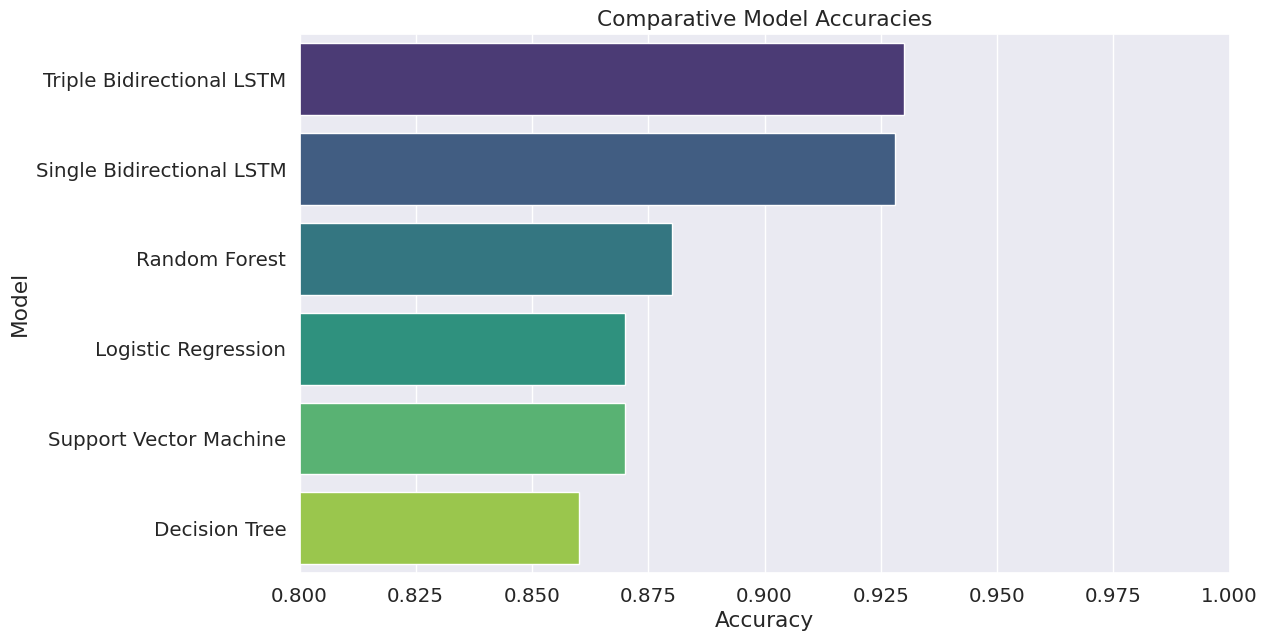

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=all_models.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Comparative Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.8, 1.0) # Set x-axis limit for better comparison of high accuracies
plt.show()

### LIME explanation for LSTM Model

In [ ]:
explainer_lstm = LimeTextExplainer(class_names=le.classes_)

# Choose a sample text from the test set for explanation
idx_to_explain = 15 # You can change this index to explore different texts
sample_text = X_test[idx_to_explain]

# The LSTM model expects padded sequences as input
def predict_proba_lstm(texts):
    processed_texts = []
    for text in texts:
        # Normalize the text using the same function used for training
        normalized = normalized_sentence(text)
        # Tokenize and pad the sequence
        seq = tokenizer.texts_to_sequences([normalized])
        padded_seq = pad_sequences(seq, maxlen=maxlen, truncating='pre')
        processed_texts.append(padded_seq[0]) # Take the first (and only) item

    # Convert list of arrays to a single numpy array
    processed_texts = np.array(processed_texts)

    # Predict probabilities using the LSTM model
    return model.predict(processed_texts, verbose=0)


# Explain the instance
print(f"Original Text: {df_test.iloc[idx_to_explain]['Text']}")
print(f"True Emotion: {le.inverse_transform([np.argmax(y_test[idx_to_explain])])[0]}")
predicted_emotion_idx = np.argmax(model.predict(np.expand_dims(sample_text, axis=0), verbose=0), axis=-1)[0]
print(f"Predicted Emotion: {le.classes_[predicted_emotion_idx]}\n")

explanation = explainer_lstm.explain_instance(
    ' '.join(tokenizer.index_word[i] for i in sample_text if i != 0),
    predict_proba_lstm,
    num_features=5,
    num_samples=5000
)

explanation.show_in_notebook(text=True)

Original Text: feeling heartbroken im sure katniss
True Emotion: sadness
Predicted Emotion: sadness



LIME (Local Interpretable Model-agnostic Explanations — локальные интерпретируемые, не зависящие от модели объяснения) — это метод, который помогает нам понять, почему сложная модель "черного ящика", такая как наша двунаправленная LSTM, сделала конкретное предсказание для одной точки данных. Вот пошаговый процесс, который LIME использует для текста:

Возмущение (Perturbation): LIME начинает с вашего оригинального текста ("feeling heartbroken im sure katniss") и создает множество слегка измененных версий (известных как 'возмущенные' образцы). Для текста это обычно означает случайное удаление некоторых слов из оригинального предложения или их замену.

Предсказания "черного ящика" (Black-Box Predictions): Для каждого из этих сотен или тысяч возмущенных текстов LIME просит нашу обученную модель LSTM предсказать вероятность для каждой эмоции (радость, грусть, гнев и т.д.). Таким образом, LSTM выдает набор вероятностей для каждого измененного предложения.

Обучение локальной модели (Local Model Training): LIME не пытается понять всю сложную модель LSTM. Вместо этого он фокусируется локально вокруг оригинального текста. Он присваивает веса возмущенным образцам в зависимости от того, насколько они похожи на оригинальный текст. Затем он обучает простую, интерпретируемую модель (например, линейную регрессию) на этих взвешенных возмущенных образцах и их соответствующих предсказаниях от LSTM.

Важность признаков (Feature Importance): Коэффициенты этой простой локальной модели показывают, какие слова (признаки) оказали наибольшее влияние на предсказание LSTM для оригинального предложения. Если слово имеет высокий положительный коэффициент для "грусти", это означает, что когда это слово присутствовало, LSTM с большей вероятностью предсказывала "грусть". Если оно имело отрицательный коэффициент, его присутствие отталкивало предсказание от "грусти".

Применение к нашему примеру: Когда LIME проанализировал "feeling heartbroken im sure katniss" и определил, что это "грусть", он, вероятно, выполнил следующее:

Он сгенерировал вариации, такие как "feeling heartbroken sure katniss", "heartbroken im sure", "feeling im katniss" и т.д.
Он заметил, что когда слово "heartbroken" присутствовало, модель LSTM последовательно присваивала высокую вероятность "грусти". Когда "heartbroken" было удалено из возмущенных образцов, вероятность "грусти" от LSTM значительно падала.
И наоборот, другие слова (такие как "im", "sure", "katniss"), вероятно, имели гораздо меньшее или даже слегка отрицательное влияние на предсказание "грусти".
Поэтому в визуализации LIME вы увидели бы слово "heartbroken" выделенным зеленым цветом с сильным положительным весом, что указывает на то, что оно было основным фактором для предсказания "грусти" моделью LSTM в этом конкретном предложении.

In [ ]:
print(f"Verifying files in {destination_folder}:")
!ls -l "{destination_folder}"

Verifying files in /content/drive/MyDrive/Emotion_Recognition_Model_Assets:
total 35129
-rw------- 1 root root      284 Mar 16 18:47 emotion_recognition_metadata.json
-rw------- 1 root root 35399062 Mar 16 18:47 emotion_recognition_model.keras
-rw------- 1 root root      292 Mar 16 18:47 label_encoder.pkl
-rw------- 1 root root   571820 Mar 16 18:47 tokenizer.pkl
